# Skeletal Data Extraction

In [6]:
import numpy as np

def parse_single_skeleton(file_path):
    with open(file_path, 'r') as f:
        datas = f.readlines()
    
    if not datas:
        return None

    nframe = int(datas[0].strip())
    njoints = 25
    max_body = 2 #NTU 60 only have a max of 2 people

    #initial zeros for (T, M, V, C) -> (Frames, Bodies, Joints, Coordinates) - n.b. Coordinates 3 cuz just (x,y,z)
    skeleton_tensor = np.zeros((nframe, max_body, njoints, 3), dtype=np.float32)

    cursor = 0
    for frame in range(nframe):
        cursor += 1
        bodycount = int(datas[cursor].strip())

        if bodycount == 0:
            continue

        actual_bodies = min(bodycount, max_body) #capping it to the max of 2 bodies

        for body in range(bodycount):
            cursor += 1 #skip kinect metadata
            cursor += 1
            njoints_in_file = int(datas[cursor].strip())

            for joint in range(njoints_in_file):
                cursor += 1
                if body < max_body:
                    joininfo = datas[cursor].strip().split()
                    skeleton_tensor[frame, body, joint, :] = [float(joininfo[0]), float(joininfo[1]), float(joininfo[2])] #appends the (x,y,z)
    
    return skeleton_tensor

In [7]:
file_path = '../data/raw_skeletons/nturgb+d_skeletons_s001_to_s017/S001C001P001R001A010.skeleton'
tensor_data = parse_single_skeleton(file_path)

print(f"Skeleton Data (Frames, Bodies, Joints, Coordinates): {tensor_data.shape}")

Skeleton Data (Frames, Bodies, Joints, Coordinates): (69, 2, 25, 3)


# Data Visualization

In [8]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def create_skeleton_gif(tensor_data, body_idx=0, save_path="ntu_action.gif"):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    bones = [
        (0, 1), (1, 20), (2, 20), (3, 2), (4, 20), (5, 4), (6, 5), (7, 6), 
        (8, 20), (9, 8), (10, 9), (11, 10), (12, 0), (13, 12), (14, 13), 
        (15, 14), (16, 0), (17, 16), (18, 17), (19, 18), (21, 22), 
        (22, 7), (23, 24), (24, 11)
    ]

    # This function redraws the skeleton for every single frame
    def update(frame_idx):
        ax.clear() # Wipe the previous frame
        
        # We MUST lock the camera boundaries, otherwise the camera will bounce 
        # around wildly as the person moves, making the video unwatchable.
        ax.set_xlim(-1, 1)
        ax.set_ylim(2, 5) 
        ax.set_zlim(-1, 1)
        
        ax.set_title(f'NTU Skeleton - Frame {frame_idx}')
        ax.set_xlabel('X (Meters)')
        ax.set_ylabel('Depth (Z Meters)')
        ax.set_zlabel('Height (Y Meters)')
        
        joints = tensor_data[frame_idx, body_idx]
        
        # Skip if zero-padded
        if np.all(joints[0] == 0):
            return
            
        xs, ys, zs = joints[:, 0], joints[:, 1], joints[:, 2]
        
        # Draw the joints
        ax.scatter(xs, zs, ys, c='red', s=40)
        
        # Draw the bones
        for bone in bones:
            j1, j2 = bone
            ax.plot([xs[j1], xs[j2]], [zs[j1], zs[j2]], [ys[j1], ys[j2]], c='blue', linewidth=2)

    # Calculate total frames from the tensor shape
    num_frames = tensor_data.shape[0]
    
    print(f"Compiling {num_frames} frames into a GIF... Please wait.")
    
    # Run the animation loop (interval=50 means 50 milliseconds per frame, or 20 FPS)
    ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=50)
    
    # Save it using the Pillow library (which is built into standard Python environments)
    ani.save(save_path, writer='pillow', fps=20)
    
    print(f"Success! Saved to {save_path}")
    plt.close() # Hides the messy static plot

# --- RENDER THE VIDEO ---
# Make sure your tensor_data variable from the previous cell is loaded!
create_skeleton_gif(tensor_data, body_idx=0, save_path="action_test.gif")

Compiling 69 frames into a GIF... Please wait.
Success! Saved to action_test.gif


# Building GCN Layer

In [10]:
import torch
import torch.nn as nn

class Spatial_GCN_Layer(nn.Module):
    def __init__(self, in_channels=3, out_channels=64, num_joints=25):
        super().__init__()

        #Learnable bones -> Shape:(25,25)
        self.adj_matrix = nn.Parameter(torch.randn(num_joints,num_joints))
        self.linear = nn.Linear(in_channels, out_channels)
        self.relu = nn.ReLU()
    
    def forward(self,x):
        # x -> has an input shape of (Batch, Time, Joints, Channels)
        
        #Step A: Expand the features -> e.g 3 channels to 64 channels
        x = self.linear(x)

        #Step B: The Graph Convolution (Message Passing)
        out = torch.einsum('btjc, jk -> btkc', x, self.adj_matrix)

        #Step C: Apply Activation Function
        out = self.relu(out)
        
        return out


In [13]:
# 1. Take from the previous tensor data
numpy_body_0 = tensor_data[:, 0, :, :]

# 2. PyTorch expects 'Batch' so we use unsqueeze(0) as a workaround
torch_input = torch.tensor(numpy_body_0, dtype=torch.float32).unsqueeze(0)

# 3. Intialize new GCN Layer
gcn_layer = Spatial_GCN_Layer(in_channels=3, out_channels=64, num_joints=25)

# 4. Forward Pass
output_tensor = gcn_layer(torch_input)

print(f"Input Tensor Shape:  {torch_input.shape}  -> (Batch, Time, Joints, Coordinates)")
print(f"Output Tensor Shape: {output_tensor.shape} -> (Batch, Time, Joints, Extracted_Features)")

Input Tensor Shape:  torch.Size([1, 103, 25, 3])  -> (Batch, Time, Joints, Coordinates)
Output Tensor Shape: torch.Size([1, 103, 25, 64]) -> (Batch, Time, Joints, Extracted_Features)


# The Temporal Brain (The Transformer)

### SAFE TO RUN: Visualizes the Global Node Topology. (Just a Simulator not the real deal)

In [15]:
# Safe to run in CPU
import numpy as np
import matplotlib.pyplot as plt

# 1. Mapping the joints
left_arm = [4, 5, 6, 7, 21, 22]
right_arm = [8, 9, 10, 11, 23, 24]
left_leg = [12, 13, 14, 15]
right_leg = [16, 17, 18, 19]
torso = [0, 1, 2, 3, 20]

# Create lookup arr -> index = joint ; value = room ID
joint_rooms = np.zeros(25, dtype=int)
for j in left_arm: joint_rooms[j] = 1
for j in right_arm: joint_rooms[j] = 2
for j in left_leg: joint_rooms[j] = 3
for j in right_leg: joint_rooms[j] = 4
for j in torso: joint_rooms[j] = 5

# 2. Build Mask grid -> 25 joints + 1 global node = 26 tokens
num_tokens = 26
global_node_idx = 25

# intialize empty grid
attention_mask = np.zeros((num_tokens, num_tokens))

# 3. Apply custom routing logic
for i in range(num_tokens):
    for j in range(num_tokens):
        # RULE A: The Project Manager. The Global Node sees everything, and everything sees it.
        if i == global_node_idx or j == global_node_idx:
            attention_mask[i,j] = 1
        elif i < 25 and j <25 and joint_rooms[i] == joint_rooms[j]:
            attention_mask[i,j] = 1

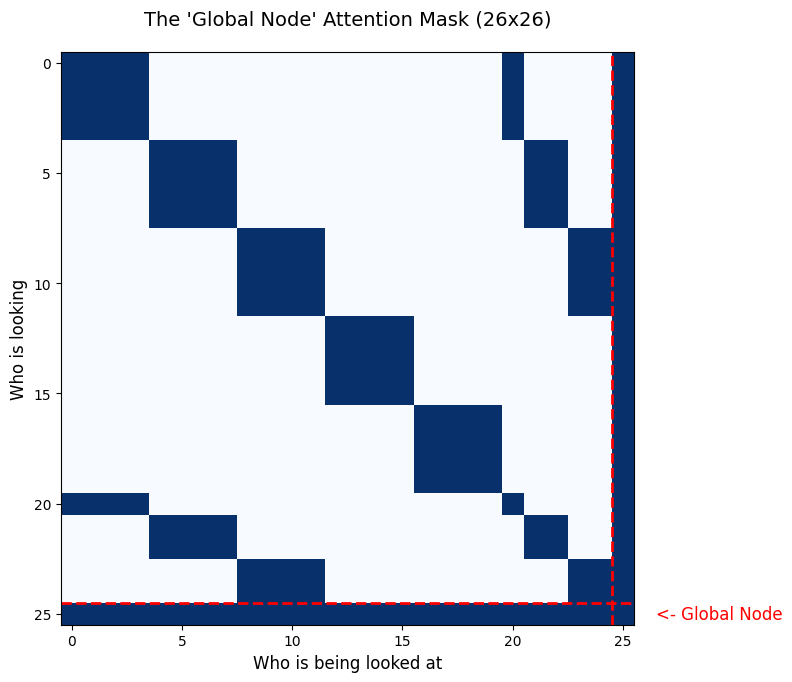

Total connections in a Standard Transformer: 676
Total connections in our Hub-and-Spoke Mask: 180
Compute Reduction: 73.4%


In [16]:
# Mask Visualization
plt.figure(figsize=(8, 8))
# We plot the grid. Dark blue = 1 (Connection Allowed). White = 0 (Connection Blocked).
plt.imshow(attention_mask, cmap='Blues', interpolation='nearest')

plt.title("The 'Global Node' Attention Mask (26x26)", fontsize=14, pad=20)
plt.xlabel("Who is being looked at", fontsize=12)
plt.ylabel("Who is looking", fontsize=12)

# Draw red lines to highlight the Global Node's domain
plt.axhline(24.5, color='red', linewidth=2, linestyle='--')
plt.axvline(24.5, color='red', linewidth=2, linestyle='--')
plt.text(26.5, 25, '<- Global Node', color='red', fontsize=12, verticalalignment='center')

plt.tight_layout()
plt.show()

# Print the efficiency metric
total_possible = 26 * 26
actual_computed = np.sum(attention_mask)
print(f"Total connections in a Standard Transformer: {total_possible}")
print(f"Total connections in our Hub-and-Spoke Mask: {int(actual_computed)}")
print(f"Compute Reduction: {100 - (actual_computed/total_possible)*100:.1f}%")

### DO NOT RUN FORWARD PASS ON LAPTOP - REQUIRES RTX 3090 TRITON COMPILER.

In [17]:
# import torch
# import torch.nn as nn
# # Import the cutting-edge FlexAttention APIs
# from torch.nn.attention.flex_attention import flex_attention, create_block_mask

# class Temporal_Brain_Layer(nn.Module):
#     def __init__(self, embed_dim=64, num_heads=4, num_joints=25):
#         super().__init__()
#         self.embed_dim = embed_dim
#         self.num_heads = num_heads
        
#         # Standard projections for Queries, Keys, and Values
#         self.qkv_proj = nn.Linear(embed_dim, embed_dim * 3)
#         self.out_proj = nn.Linear(embed_dim, embed_dim)
        
#         # 1. Define the 5 Anatomical Rooms (0-indexed)
#         # We use a tensor here so the GPU compiler can read it fast
#         room_mapping = [
#             5, 5, 5, 5, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 
#             5, 1, 1, 2, 2  # The 25 joints mapped to rooms 1-5
#         ]
#         self.register_buffer('room_map', torch.tensor(room_mapping, dtype=torch.int32))
        
#         # The Global Node is the 26th token (index 25)
#         self.global_node_idx = 25 

#     # 2. The FlexAttention Masking Rule
#     # This function tells the hardware exactly which tokens are allowed to communicate
#     def anatomical_mask_rule(self, b, h, q_idx, kv_idx):
#         # b = batch, h = head, q_idx = "Who is looking", kv_idx = "Who is being looked at"
        
#         # Rule A: The Project Manager. If either token is the Global Node, ALLOW connection.
#         is_global_q = (q_idx == self.global_node_idx)
#         is_global_kv = (kv_idx == self.global_node_idx)
        
#         # Rule B: The Soundproof Rooms. Do they share the same room ID?
#         # We add a safety check (< 25) to avoid indexing out of bounds for the global node
#         same_room = (q_idx < 25) & (kv_idx < 25) & (self.room_map[q_idx] == self.room_map[kv_idx])
        
#         # Final Verdict: Allow connection if it's the global node, OR if they are in the same room.
#         return is_global_q | is_global_kv | same_room

#     def forward(self, x):
#         # x shape: (Batch, Sequence_Length, Embed_Dim)
#         # Sequence Length here is our 25 joints + 1 Global Node = 26 tokens
#         B, S, E = x.shape 
        
#         # 1. Generate Queries, Keys, and Values
#         qkv = self.qkv_proj(x)
        
#         # 2. Reshape for Multi-Head Attention: (Batch, Heads, Sequence, Head_Dim)
#         qkv = qkv.view(B, S, 3, self.num_heads, E // self.num_heads)
#         qkv = qkv.permute(2, 0, 3, 1, 4)
#         q, k, v = qkv[0], qkv[1], qkv[2]
        
#         # 3. Compile the Hardware-Sparse Mask!
#         # This is where the Triton compiler writes the custom instruction for the RTX 3090
#         block_mask = create_block_mask(self.anatomical_mask_rule, B, self.num_heads, S, S)
        
#         # 4. Execute FlexAttention
#         # The GPU will physically skip computing the O(N^2) empty space
#         attn_output = flex_attention(q, k, v, block_mask=block_mask)
        
#         # 5. Reshape and project back out
#         attn_output = attn_output.permute(0, 2, 1, 3).contiguous().view(B, S, E)
#         out = self.out_proj(attn_output)
        
#         return out

# print("Temporal Brain Blueprint successfully written to memory.")

# XAI Extraction

In [18]:
import numpy as np

def extract_xai_red_dots(attention_matrix):
    # attention_matrix.shape -> (26,26)

    # 1. Isolate Global Node -> So only see the connections of 0-24 (The physical joints)
    global_node_weights = attention_matrix[25, :25]

    # 2. The Math (Min-Max Normalization)
    # The raw attention numbers can be very small decimals. 
    # We normalize them so the least important joint is exactly 0.0 (Cold) 
    # and the most important joint is exactly 1.0 (Red Hot).
    min_val = np.min(global_node_weights)
    max_val = np.max(global_node_weights)

    # We add 1e-8 (a tiny number) to prevent dividing by zero if the array is flat
    heat_scores = (global_node_weights - min_val) / (max_val - min_val + 1e-8)
    
    return heat_scores


In [19]:
# Testing XAI Engine
# We will create a fake attention matrix filled with low-level background noise...
simulated_attention = np.random.rand(26, 26) * 0.1
# ...but we will manually inject massive attention spikes into the exact joints 
# used for drinking water (Right Hand, Right Wrist, and Head).
simulated_attention[25, 11] = 0.95  # Right Hand (Joint 11)
simulated_attention[25, 10] = 0.80  # Right Wrist (Joint 10)
simulated_attention[25, 3] = 0.85   # Head (Joint 3)

# 1. Run our extraction hook
joint_heat_map = extract_xai_red_dots(simulated_attention)

# 2. Find and print the Top 3 most important joints
# argsort sorts lowest to highest, so we take the last 3 [-3:] and reverse them [::-1]
top_3_joints = np.argsort(joint_heat_map)[-3:][::-1]

print("🔍 XAI Analysis Complete. The AI's focus has been extracted.")
print("-" * 50)
for rank, joint_idx in enumerate(top_3_joints):
    score = joint_heat_map[joint_idx]
    print(f"Rank #{rank+1}: Joint {joint_idx:02d} | Heat Score: {score:.2f}")

🔍 XAI Analysis Complete. The AI's focus has been extracted.
--------------------------------------------------
Rank #1: Joint 11 | Heat Score: 1.00
Rank #2: Joint 03 | Heat Score: 0.89
Rank #3: Joint 10 | Heat Score: 0.84
